## Examples: Neural network classifiers

#### In this notebook, we'll get an overview of Neural networks as advanced classification algorithms.

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Obtain a basic understanding of the architecture and fundamental elements of an artificial neural network.
#### - Understand how to use TensorFlow layers to build a neural network architecture.
#### - Understand how a model is trained and evaluated using a validation split.
#### - Implement an effective neural network for classification using keras

In [1]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential
from matplotlib import pyplot as plt
from random import randint
from tensorflow.keras.utils import to_categorical

### Preparing the data

In [2]:
# Preparing the dataset
# setup train and test splits
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Making a copy before flattening for the next code-segment which displays images
X_train_drawing = X_train

print('X_train shape: ', X_train.shape) # (60000, 28, 28)
print('y_train shape: ', y_train.shape) # (60000,)

# Convert class vectors to binary class matrices
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

X_train shape:  (60000, 28, 28)
y_train shape:  (60000,)


In [3]:
# Normalise the images
X_train = (X_train / 255) - 0.5
X_test = (X_test / 255) - 0.5

# Flatten the images
X_train = X_train.reshape((-1, 784))
X_test = X_test.reshape((-1, 784))

print(X_train.shape) # (60000, 784)
print(X_test.shape) # (10000, 784)

(60000, 784)
(10000, 784)


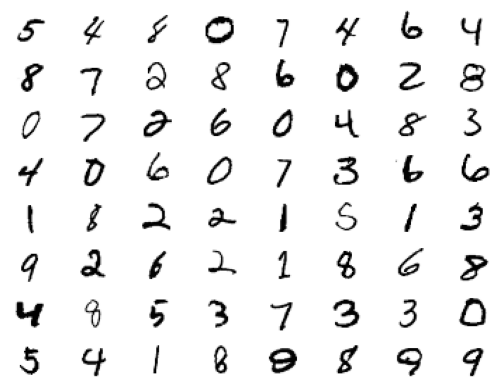

In [4]:
for i in range(64):
    ax = plt.subplot(8, 8, i+1)
    ax.axis('off')
    plt.imshow(X_train_drawing[randint(0, X_train.shape[0])], cmap='Greys')

### Building the model

In [5]:
model = Sequential([
    Input(shape=(784,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax'),
])

### Compiling the model

In [6]:
# compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

### Training and evaluating the model

In [7]:
print(tf.__version__)

2.21.0


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8849 - loss: 0.3775 - val_accuracy: 0.9435 - val_loss: 0.1872
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9410 - loss: 0.1932 - val_accuracy: 0.9628 - val_loss: 0.1339
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9547 - loss: 0.1463 - val_accuracy: 0.9550 - val_loss: 0.1467
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9621 - loss: 0.1219 - val_accuracy: 0.9730 - val_loss: 0.0969
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9669 - loss: 0.1065 - val_accuracy: 0.9705 - val_loss: 0.0983
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9700 - loss: 0.0960 - val_accuracy: 0.9758 - val_loss: 0.0873
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9731 - loss: 0.0860 - val_accuracy: 0.9750 - val_loss: 0.0861
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9753 - loss: 0.0777 - 

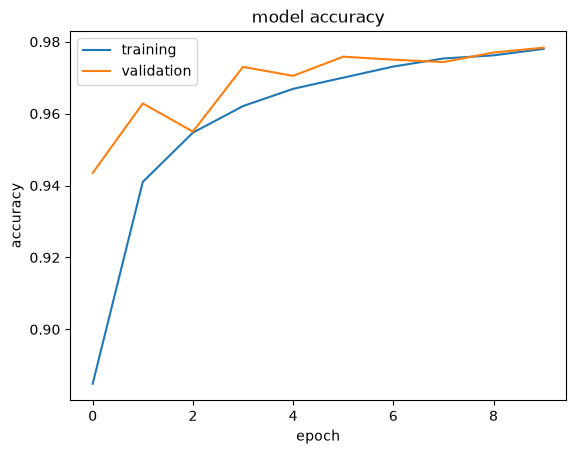

Test loss: 0.0942
Test accuracy: 0.972


In [8]:
# Training the model
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=10,
    verbose=True,
    validation_split=0.1
)

# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=False)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='best')
plt.show()

print(f'Test loss: {loss:.3}')
print(f'Test accuracy: {accuracy:.3}')

In [9]:
predictions = model.predict(X_test)

predicted_classes = predictions.argmax(axis=1)

print(predicted_classes[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [10]:
np.bincount(predicted_classes)

array([ 990, 1140, 1009, 1057,  996,  865,  977, 1031,  952,  983])

### Making predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


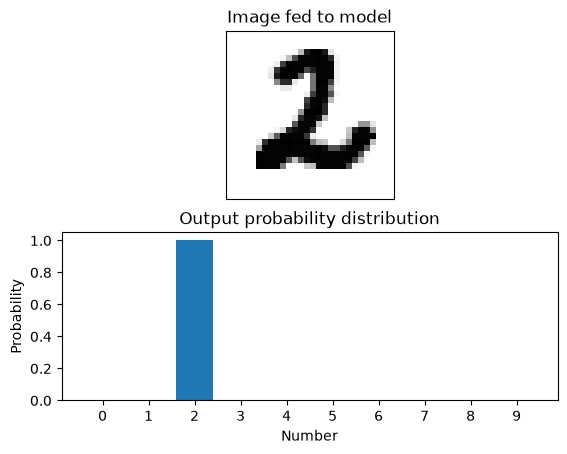

Top prediction: 2


In [11]:
# select an image at random to feed to our model
idx = np.random.randint(len(X_train))

prediction = model.predict(X_train[[idx]])[0]

fig, ax = plt.subplots(2, 1)

ax[0].imshow(X_train_drawing[idx], cmap='Greys')
ax[0].set_xticks(())
ax[0].set_yticks(())
ax[0].set_title('Image fed to model')

ax[1].bar(range(0, 10), prediction)
ax[1].set_xticks(range(0, 10))
ax[1].set_xlabel('Number')
ax[1].set_ylabel('Probability')
ax[1].set_title('Output probability distribution')

plt.show()

print(f'Top prediction: {prediction.argmax()}')